In [8]:
import sys
!{sys.executable} -m pip install torchdiffeq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 11.6 MB/s  0:00:03m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [torchdiffeq]


In [ ]:
!{sys.executable} -m pip install pysindy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 10.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [pysindy]m5/7 [derivative]n]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torchdiffeq import odeint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parameters
k1 = k2 = k3 = k4 = 10.0
c1 = c2 = c3 = c4 = 0.5
m1 = m2 = m3 = m4 = 1.0
k_nl_true = 2.0

# Mass matrix (all ones -> identity)
M = torch.eye(4, device=device)

# Stiffness matrix K for a 4-DOF shear building (fixed base)
K = torch.tensor([
    [k1 + k2,   -k2,       0.0,      0.0],
    [-k2,       k2 + k3,  -k3,       0.0],
    [0.0,      -k3,       k3 + k4,  -k4],
    [0.0,       0.0,      -k4,       k4]
], dtype=torch.float32, device=device)

# Damping matrix (diagonal with c1..c4)
C = torch.diag(torch.tensor([c1, c2, c3, c4], dtype=torch.float32, device=device))

# Initial conditions (8D state: [x1,x2,x3,x4,v1,v2,v3,v4])
h0_1 = torch.tensor([ 2.0,  0.0, 0.0, 0.0,  0.0, -2.0, 0.0, 0.0], dtype=torch.float32, device=device)
h0_2 = torch.tensor([-2.0,  0.0, 0.0, 3.0, -2.0,  0.0, 0.0, 0.0], dtype=torch.float32, device=device)
h0_3 = torch.tensor([ 0.0,  4.0, 0.0, 0.0,  0.0,  0.0, 0.0, 0.0], dtype=torch.float32, device=device)

# Time grids
dt = 0.01
t_train_end = 6.0
t_test_end = 12.0

# Same dt for train/test
t_train = torch.linspace(0.0, t_train_end, int(t_train_end / dt) + 1, device=device)
t_test  = torch.linspace(0.0, t_test_end,  int(t_test_end  / dt) + 1, device=device)


In [11]:
def ground_truth_rhs(t, h):

    x = h[:4]
    v = h[4:]

    # Linear restoring + damping: -Kx - Cv
    lin_force = -K @ x - C @ v

    # Cubic nonlinearity on DOF 1 only
    f_nl = torch.zeros_like(x)
    f_nl[0] = -k_nl_true * x[0]**3

    # Total acceleration (M = I)
    a = lin_force + f_nl

    dh = torch.zeros_like(h)
    dh[:4] = v      # x' = v
    dh[4:] = a      # v' = a
    return dh

In [ ]:
import torch


class PINODEFunc4DOF(nn.Module):
    def __init__(self, K: torch.Tensor, C: torch.Tensor, scheme: int):
        super().__init__()

        if scheme not in (1, 2, 3):
            raise ValueError(f"scheme must be 1, 2, or 3, got {scheme}")

        self.scheme = scheme

        if scheme == 1:
            K_eff = torch.zeros_like(K)
            C_eff = torch.zeros_like(C)
        elif scheme == 2:
            K_eff = 0.7 * K.clone()
            C_eff = 0.7 * C.clone()
        else:  # scheme == 3
            K_eff = K.clone()
            C_eff = C.clone()

        self.K = nn.Parameter(K_eff, requires_grad=False)
        self.C = nn.Parameter(C_eff, requires_grad=False)

        self.mlp = nn.Sequential(
            nn.Linear(8, 30),
            nn.Tanh(),
            nn.Linear(30, 4),
        )

    def forward(self, t, h):
        x = h[..., :4]
        v = h[..., 4:]

        dv_phys = (
            -self.K @ x.unsqueeze(-1)
            -self.C @ v.unsqueeze(-1)
        ).squeeze(-1)

        dv_corr = self.mlp(h)

        dh = torch.zeros_like(h)
        dh[..., :4] = v
        dh[..., 4:] = dv_phys + dv_corr
        return dh

In [13]:
@torch.no_grad()
def generate_trajectory(h0, t_grid):

    # This is the reference trajectory
    sol = odeint(ground_truth_rhs, h0, t_grid, method='rk4')  # (T, 8)
    return sol


print("Generating ground truth data...")
# Training trajectories (0–6s)
traj1_train = generate_trajectory(h0_1, t_train)  # IC1
traj2_train = generate_trajectory(h0_2, t_train)  # IC2

# Test/generalization trajectories (0–12s)
traj2_test = generate_trajectory(h0_2, t_test)    # IC2
traj3_test = generate_trajectory(h0_3, t_test)    # IC3

Generating ground truth data...


In [ ]:
def discrepancy_reference(x, v, scheme, K, C, k_nl):
    # x, v: (T,4)

    # Linear part in standard form: Kx + Cv
    lin = torch.matmul(x, K.T) + torch.matmul(v, C.T)

    # Nonlinear force only on DOF1: k_nl * x1^3
    f_nl = torch.zeros_like(x)
    f_nl[:, 0] = k_nl * x[:, 0]**3

    # True acceleration according to full physics: a_true = -(Kx + Cv + f_nl)
    a_true = -(lin + f_nl)

    # Depending on the scheme, discrepancy is defined differently
    if scheme == 1:
        # Scheme 1 has no physics in v', so discrepancy = full true acceleration
        a_disc = a_true
    elif scheme == 2:
        # Scheme 2 uses a_phy = -0.7(Kx + Cv)
        a_phy = -0.7 * lin
        # discrepancy = a_true - a_phy = missing 0.3*lin - f_nl
        a_disc = a_true - a_phy
    elif scheme == 3:
        # Scheme 3 uses full linear physics a_phy = -lin
        a_phy = -lin
        # discrepancy = a_true - a_phy = -f_nl (pure nonlinear)
        a_disc = a_true - a_phy
    else:
        raise ValueError("scheme must be 1, 2, or 3")

    return a_disc

def true_discrepancy_on_traj(scheme, traj):
    # traj: (T,8) [x(4), v(4)] along a TRUE trajectory
    x = traj[..., :4]
    v = traj[..., 4:]
    # This returns the analytic discrepancy a_disc(T,4) for that scheme
    return discrepancy_reference(x, v, scheme=scheme, K=K, C=C, k_nl=k_nl_true)


def train_scheme_with_disc(scheme, model, num_epochs=200, lr=1e-3, lambda_disc=1.0):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()
    epochs_ic1 = num_epochs // 4
    epochs_ic2 = num_epochs - epochs_ic1

    # Phase 1: train only on IC1 for 1250 epochs
    for epoch in range(1, epochs_ic1):
        opt.zero_grad()

        # Model trajectory for IC1
        pred1 = odeint(model, h0_1, t_train, method='rk4')

        # Data loss for IC1 only
        loss_state = mse(pred1, traj1_train)

        # Discrepancy supervision on TRUE traj1
        with torch.no_grad():
            disc1_true = true_discrepancy_on_traj(scheme, traj1_train)

        disc1_nn = model.mlp(traj1_train)
        loss_disc = mse(disc1_nn, disc1_true)

        loss = loss_state + lambda_disc * loss_disc
        loss.backward()
        opt.step()

        if epoch % 100 == 0 or epoch == 1:
            print(f"[{scheme}] Epoch {epoch:4d}, loss = {loss.item():.4e}")

    # Phase 2: train only on IC2 for 3750 epochs
    for epoch in range(1, epochs_ic2):
        opt.zero_grad()

        # Model trajectory for IC2
        pred2 = odeint(model, h0_2, t_train, method='rk4')

        # Data loss for IC2 only
        loss_state = mse(pred2, traj2_train)

        # Discrepancy supervision on TRUE traj2
        with torch.no_grad():
            disc2_true = true_discrepancy_on_traj(scheme, traj2_train)

        disc2_nn = model.mlp(traj2_train)
        loss_disc = mse(disc2_nn, disc2_true)

        loss = loss_state + lambda_disc * loss_disc
        loss.backward()
        opt.step()

        if epoch % 100 == 0 or epoch == 1:
            print(f"[{scheme}] Epoch {epoch:4d}, loss = {loss.item():.4e}")

    return model


@torch.no_grad()
def evaluate_scheme(scheme_name, model):

    loss_fn = nn.MSELoss()

    # IC2, 0–12s
    pred2 = odeint(model, h0_2, t_test, method='rk4')
    mse2_full = loss_fn(pred2, traj2_test).item()

    # split at 6s (same dt as train)
    mid_idx = len(t_train)
    mse2_0_6  = loss_fn(pred2[:mid_idx], traj2_test[:mid_idx]).item()
    mse2_6_12 = loss_fn(pred2[mid_idx:], traj2_test[mid_idx:]).item()

    # IC3, 0–12s
    pred3 = odeint(model, h0_3, t_test, method='rk4')
    mse3_full = loss_fn(pred3, traj3_test).item()
    mse3_0_6  = loss_fn(pred3[:mid_idx], traj3_test[:mid_idx]).item()
    mse3_6_12 = loss_fn(pred3[mid_idx:], traj3_test[mid_idx:]).item()

    print(f"\n=== Evaluation for {scheme_name} ===")
    print(f"IC2 (0–12s) MSE total: {mse2_full:.4e}")
    print(f"IC2 (0–6s)  MSE:       {mse2_0_6:.4e}")
    print(f"IC2 (6–12s) MSE:       {mse2_6_12:.4e}")
    print(f"IC3 (0–12s) MSE total: {mse3_full:.4e}")
    print(f"IC3 (0–6s)  MSE:       {mse3_0_6:.4e}")
    print(f"IC3 (6–12s) MSE:       {mse3_6_12:.4e}")


def save_model(model, path):
    torch.save(model.state_dict(), path)
    print(f"Saved model to {path}")

In [40]:
if __name__ == "__main__":

    save_path = "../models/"

    # Load already-trained models
    model1 = PINODEFunc4DOF(K, C, scheme=1)
    model1.load_state_dict(torch.load(save_path + "free_vibration_model_no_physics.pth", map_location=device), strict=False)

    model2 = PINODEFunc4DOF(K, C, scheme=2)
    model2.load_state_dict(torch.load(save_path + "free_vibration_model_partial_physics.pth", map_location=device), strict=False)

    model3 = PINODEFunc4DOF(K, C, scheme=3)
    model3.load_state_dict(torch.load(save_path + "free_vibration_model_full_linear_physics.pth", map_location=device), strict=False)

    # evaluate_scheme("Scheme 1", model1)
    # evaluate_scheme("Scheme 2", model2)
    # evaluate_scheme("Scheme 3", model3)

/tmp/ipykernel_26480/3031465497.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model1.load_state_dict(torch.load(save_path + "free_vibration_model_no_physics.pth", map_

In [41]:
import matplotlib.pyplot as plt

def plot_nn_vs_interdofs(models, schemes, h_true_list, K_true, C_true, k_nl_true, device="cpu"):

    # Concatenate true data
    h_true = torch.cat(h_true_list, dim=0).to(device)   # (N, 8)
    x = h_true[:, :4]
    v = h_true[:, 4:]

    # Inter-DOF displacement
    dx1 = x[:, 0]
    dx2 = x[:, 1] - x[:, 0]
    dx3 = x[:, 2] - x[:, 1]
    dx4 = x[:, 3] - x[:, 2]
    dx_list = [dx4, dx3, dx2, dx1]

    row_labels = [
        r"$x_4 - x_3$",
        r"$x_3 - x_2$",
        r"$x_2 - x_1$",
        r"$x_1$",
    ]

    row_dof_idx = [3, 2, 1, 0]

    scheme_titles = {
        1: "Scheme 1 (no physics)",
        2: "Scheme 2 (weak physics)",
        3: "Scheme 3 (strong physics)"
    }
    colors = {1: "tab:red", 2: "tab:blue", 3: "tab:green"}

    n_rows = 4
    n_cols = len(schemes)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4 * n_cols, 3 * n_rows),
                             squeeze=False)

    # Precompute numpy versions of x-axis (same for all schemes)
    dx_np = [d.cpu().numpy() for d in dx_list]

    # Loop over schemes
    for c, s in enumerate(schemes):
        model = models[s].to(device)
        model.eval()

        # NN(h_true):
        with torch.no_grad():
            nn_out = model.mlp(h_true).cpu().numpy()   # (N, 4)

        # Analytic discrepancy for this scheme
        a_disc = discrepancy_reference(
            x, v,
            scheme=s,
            K=K_true.to(device),
            C=C_true.to(device),
            k_nl=k_nl_true
        )
        a_disc_np = a_disc.cpu().numpy()

        # Loop over rows / DOFs
        for r in range(n_rows):
            dof_idx = row_dof_idx[r]
            ax = axes[r, c]

            xs = dx_np[r]                  # inter-DOF displacement
            nn_vals = nn_out[:, dof_idx]   # NN component (dv_i)
            ref_vals = a_disc_np[:, dof_idx]  # reference discrepancy

            # Sort by x-axis for smooth curves
            idx = np.argsort(xs)
            xs_sorted = xs[idx]
            nn_sorted = nn_vals[idx]
            ref_sorted = ref_vals[idx]

            # Reference (solid black)
            ax.plot(xs_sorted, ref_sorted,
                    color="black", linewidth=2, label="reference")

            # NN(h_true) (dotted)
            ax.plot(xs_sorted, nn_sorted,
                    linestyle=":", linewidth=2,
                    color=colors.get(s, "gray"),
                    label=f"scheme {s}")

            ax.set_ylim(-40, 60)
            ax.set_xlabel(row_labels[r])
            ax.set_ylabel(f"component {dof_idx+1}")
            ax.grid(True)

            if r == 0:
                ax.set_title(scheme_titles.get(s, f"Scheme {s}"))
                ax.legend()

    plt.tight_layout()
    plt.show()


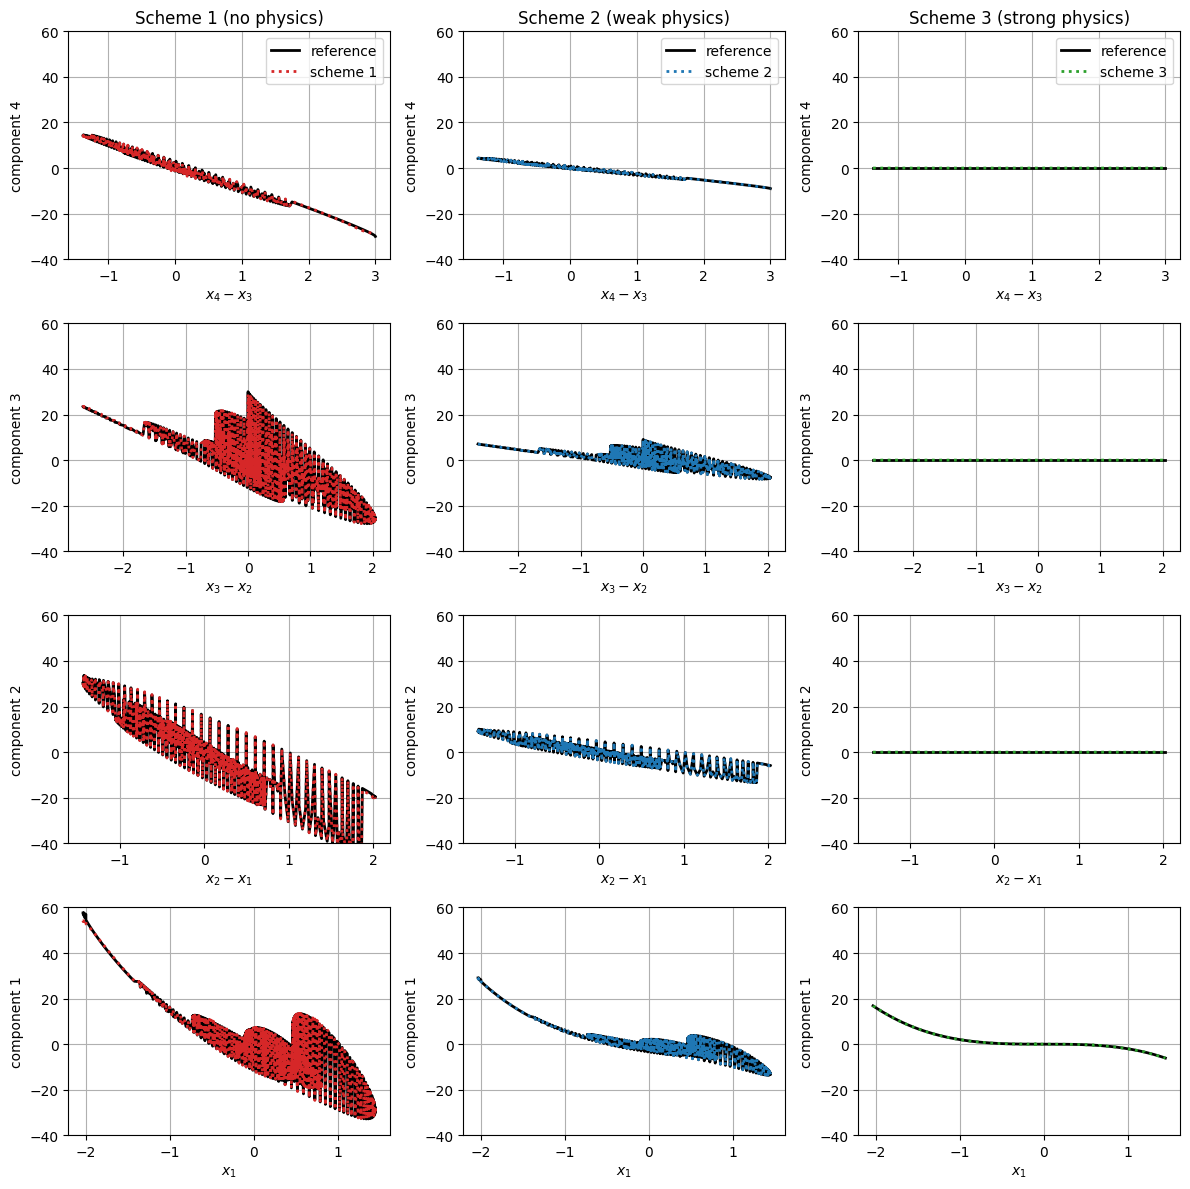

In [42]:
models = {
    1: model1,  # trained PINODEFuncScheme1
    2: model2,  # trained PINODEFuncScheme2
    3: model3,  # trained PINODEFuncScheme3
}

h_true_list = [traj2_train]

plot_nn_vs_interdofs(models=models, schemes=[1, 2, 3], h_true_list=h_true_list, K_true=K, C_true=C, k_nl_true=k_nl_true, device=device)


In [43]:
def plot_ic_results(t, gt, pred1, pred2, pred3, save_path=None):

    # Labels for the 8 state components: 4 displacements + 4 velocities
    labels = [
        "x1(t)", "x2(t)", "x3(t)", "x4(t)",
        "v1(t)", "v2(t)", "v3(t)", "v4(t)"
    ]

    # Create 4x2 grid of subplots (8 total, one per state dimension)
    fig, axes = plt.subplots(4, 2, figsize=(16, 14))
    axes = axes.flatten()   # flatten into a 1D array for easy indexing

    # Loop through the 8 states (x1..x4, v1..v4)
    for i in range(8):
        ax = axes[i]

        # Plot ground-truth trajectory
        ax.plot(t.cpu(), gt[:, i].cpu(), 'k', lw=2, label="Ground Truth")

        # Plot predictions from each PINODE scheme
        ax.plot(t.cpu(), pred1[:, i].detach().cpu(), 'b--', lw=1.5, label="Scheme 1")
        ax.plot(t.cpu(), pred2[:, i].detach().cpu(), 'r--', lw=1.5, label="Scheme 2")
        ax.plot(t.cpu(), pred3[:, i].detach().cpu(), 'g--', lw=1.5, label="Scheme 3")

        # Title of each subplot = name of that state component
        ax.set_title(labels[i])

        # x-axis label is time for all plots
        ax.set_xlabel("Time (s)")

        # Optional grid for readability
        ax.grid(True)

        # Only show legend on the first subplot to avoid repetition
        if i == 0:
            ax.legend(loc="upper right")

    # Remove overlaps / improve spacing
    plt.tight_layout()

    # Save figure to file if a path was given
    if save_path is not None:
        plt.savefig(save_path, dpi=250)

    # Display the plots
    plt.show()


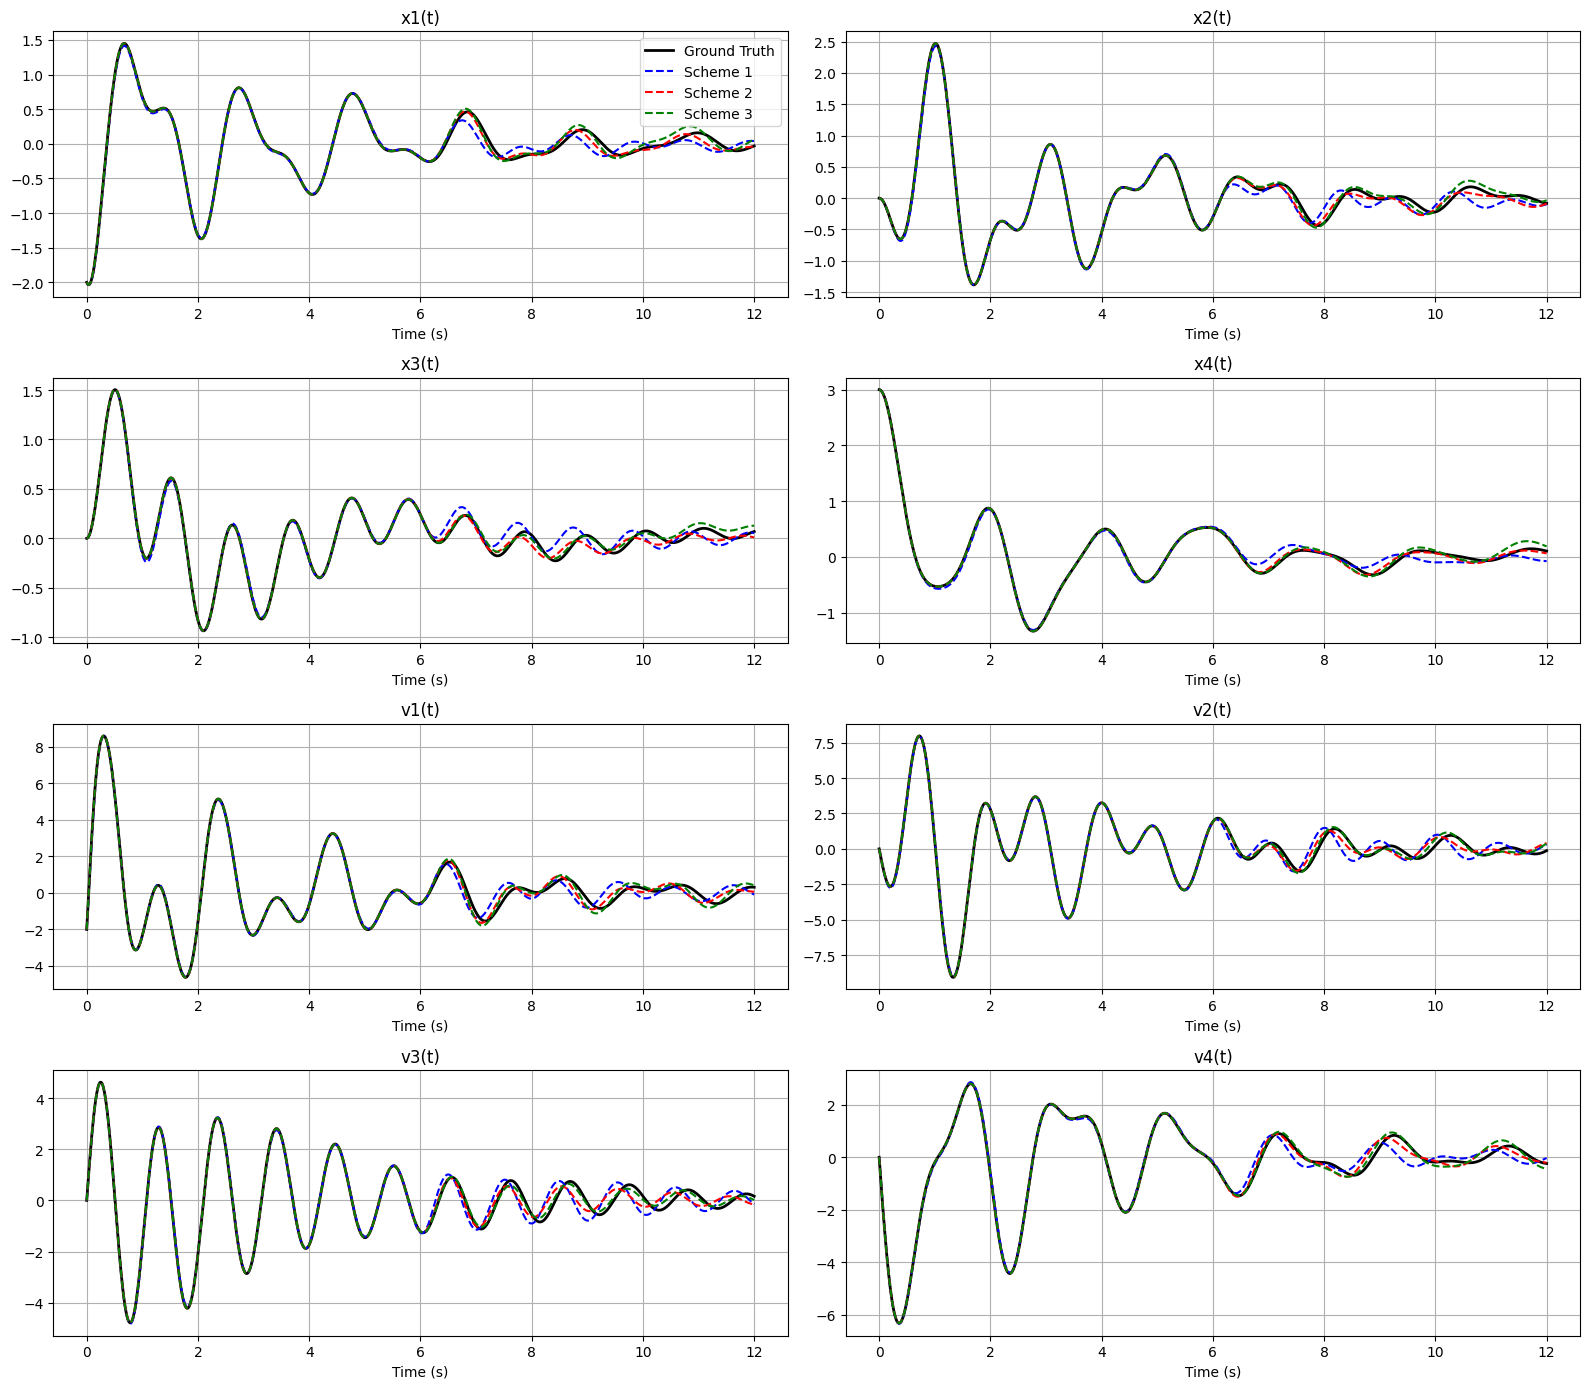

In [44]:
# --- Evaluate IC2 plot (0–12s) ---

with torch.no_grad():
    pred2_s1 = odeint(model1, h0_2, t_test, method='rk4')  # scheme 1
    pred2_s2 = odeint(model2, h0_2, t_test, method='rk4')  # scheme 2
    pred2_s3 = odeint(model3, h0_2, t_test, method='rk4')  # scheme 3

# Plot full 12 seconds
plot_ic_results(t_test, traj2_test, pred2_s1, pred2_s2, pred2_s3, save_path=None)


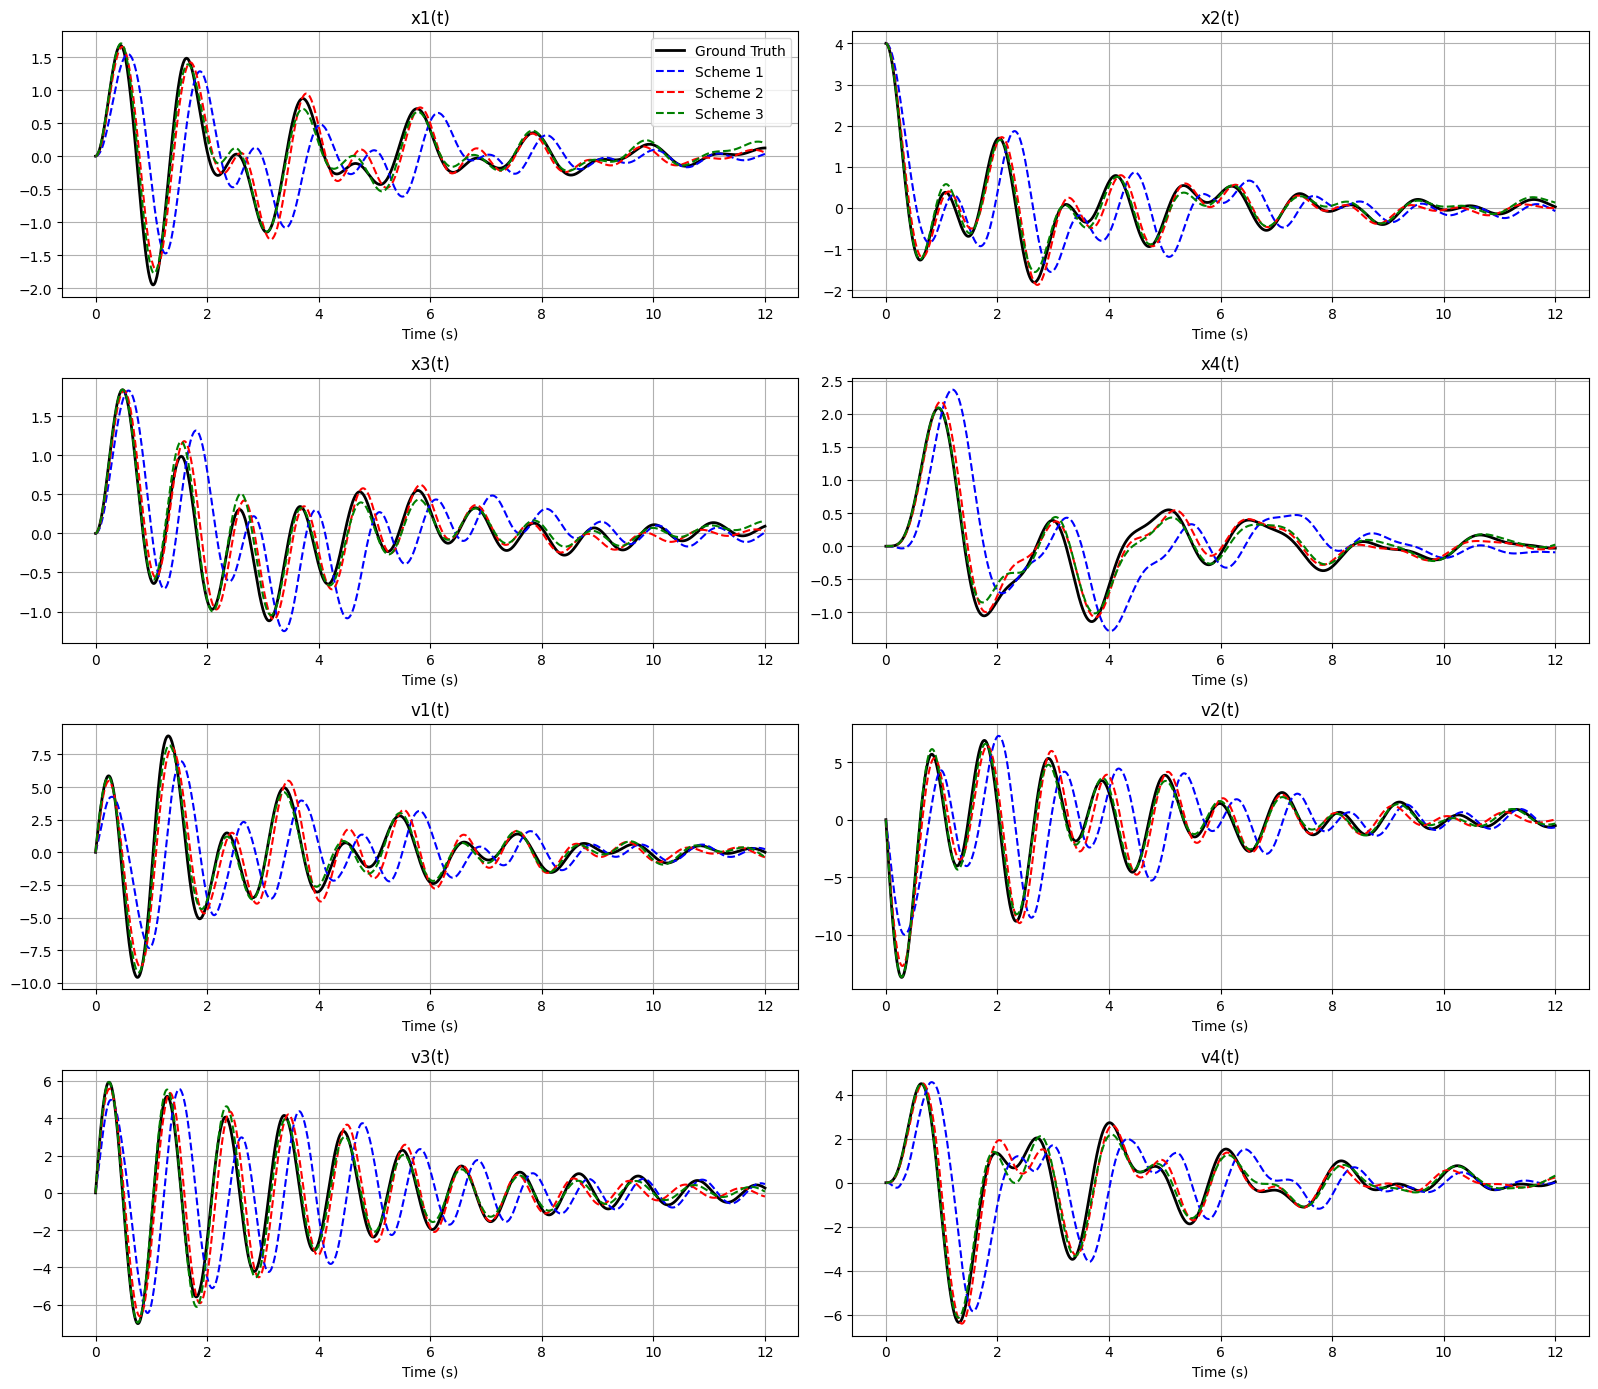

In [45]:
# --- Evaluate IC3 plot (0–12s) ---

with torch.no_grad():
    pred3_s1 = odeint(model1, h0_3, t_test, method='rk4')  # scheme 1
    pred3_s2 = odeint(model2, h0_3, t_test, method='rk4')  # scheme 2
    pred3_s3 = odeint(model3, h0_3, t_test, method='rk4')  # scheme 3

# Plot full 12 seconds
plot_ic_results(t_test, traj3_test, pred3_s1, pred3_s2, pred3_s3, save_path=None)

In [46]:
def build_sindy_discrepancy(h_true_list, scheme, K_true, C_true, k_nl_true, device="cpu"):

    # Concatenate all true trajectories into a single long dataset
    # h_true has shape (N, 8), where N = total number of time steps from all trajs
    h_true = torch.cat(h_true_list, dim=0).to(device)  # (N,8)

    # Split into displacements (x) and velocities (v)
    x = h_true[:, :4]
    v = h_true[:, 4:]

    # Compute the analytic discrepancy a_disc(x,v) for this scheme
    # using the known physics (K_true, C_true, k_nl_true).
    a_disc = discrepancy_reference(x, v, scheme,K_true.to(device), C_true.to(device), k_nl_true)  # shape (N, 4)

    # SINDy expects numpy arrays, not torch tensors
    X = h_true.cpu().numpy()   # full state [x1..x4, v1..v4]
    Y = a_disc.cpu().numpy()   # target discrepancy accelerations [dv1..dv4]

    return X, Y


In [47]:
import pysindy as ps

def run_sindy_discrepancy(h_true_list, scheme, K_true, C_true, k_nl_true, dt, threshold=0.05, device="cpu"):


    # 1) Build data (X = states, Y = discrepancy accelerations)
    #    X: (N, 8)  -> [x1..x4, v1..v4]
    #    Y: (N, 4)  -> [dv1_disc, dv2_disc, dv3_disc, dv4_disc]
    X, Y = build_sindy_discrepancy(h_true_list, scheme, K_true, C_true, k_nl_true, device=device)

    # 2) Polynomial feature library up to degree 3:
    poly_lib = ps.PolynomialLibrary(degree=3,include_interaction=False,include_bias=False)

    # 3) Sparse regression optimizer (STLSQ) with given threshold
    optimizer = ps.STLSQ(threshold=threshold, alpha=1e-5, max_iter=100)

    print(f"\n===== SINDy discrepancy equations for Scheme {scheme} =====")

    # 4) Fit 4 separate SINDy models: one for each dv_i discrepancy
    for i in range(4):
        # Select i-th component of discrepancy as target (shape (N,1))
        y_i = Y[:, i:i+1]

        # New SINDy model for this DOF
        model = ps.SINDy(feature_library=poly_lib,optimizer=optimizer)

        # We pass X as input, y_i as x_dot, and give dt for time step
        model.fit(X, t=dt, x_dot=y_i)

        # Coefficients for this DOF's equation
        coeffs = model.coefficients()[0]   # 1 row because x_dot has 1 component
        feats  = model.get_feature_names() # names of basis functions (like x0, x0^2, x0^3, ...)

        print(f"\n--- dv{i+1}_disc ---")
        terms = []
        for c, term in zip(coeffs, feats):
            # Skip exact zeros (or near-zero) terms
            if abs(c) > 1e-9:
                terms.append(f"{c:+.4f} * {term}")
        if len(terms) == 0:
            # If everything is zero, print 0
            print("0")
        else:
            # Otherwise print: dv_i = sum_j c_j * phi_j(x)
            print("dv{} = ".format(i+1) + " ".join(terms))


In [48]:
dt = 0.01

sindy_disc_s2 = run_sindy_discrepancy(h_true_list=[traj2_train],scheme=2, K_true=K, C_true=C, k_nl_true=k_nl_true, dt=dt, threshold=0.05, device=device)
sindy_disc_s3 = run_sindy_discrepancy(h_true_list=[traj2_train],scheme=3, K_true=K, C_true=C, k_nl_true=k_nl_true, dt=dt, threshold=0.05, device=device)



===== SINDy discrepancy equations for Scheme 2 =====

--- dv1_disc ---
dv1 = -6.0000 * x0 +3.0000 * x1 -0.1500 * x4 -2.0000 * x0^3

--- dv2_disc ---
dv2 = +3.0000 * x0 -6.0000 * x1 +3.0000 * x2 -0.1500 * x5

--- dv3_disc ---
dv3 = +3.0000 * x1 -6.0000 * x2 +3.0000 * x3 -0.1500 * x6

--- dv4_disc ---
dv4 = +3.0000 * x2 -3.0000 * x3 -0.1500 * x7

===== SINDy discrepancy equations for Scheme 3 =====

--- dv1_disc ---
dv1 = -2.0000 * x0^3

--- dv2_disc ---
0

--- dv3_disc ---
0

--- dv4_disc ---
0


In [50]:
def build_sindy_discrepancy_from_nn(h_true_list, model, device="cpu"):

    # Combine all TRUE trajectories (from training or test)
    # into a single dataset that SINDy will analyze
    h_true = torch.cat(h_true_list, dim=0).to(device)  # shape (N,8)

    # Evaluate the neural network on the TRUE states
    with torch.no_grad():
        a_disc_nn = model.mlp(h_true)  # shape (N,4)

    # Convert to numpy for PySINDy
    X = h_true.cpu().numpy()     # full state
    Y = a_disc_nn.cpu().numpy()  # NN discrepancy

    return X, Y


In [ ]:
def run_sindy_discrepancy_from_nn(h_true_list, model, dt, threshold=0.05, device="cpu"):


    # Build (X, Y) dataset from NN outputs
    X, Y = build_sindy_discrepancy_from_nn(h_true_list=h_true_list,model=model,device=device)
    # X: (N,8) state vectors
    # Y: (N,4) NN-generated discrepancy accelerations

    # Polynomial basis for SINDy (up to x^3, no cross terms)
    poly_lib = ps.PolynomialLibrary(degree=3,include_interaction=False,include_bias=False)

    # Sparse optimizer for selecting few active terms
    optimizer = ps.STLSQ(threshold=threshold, alpha=1e-5, max_iter=100)

    print("\n===== SINDy discrepancy equations from NN (learned) =====")

    models = []  # to store one SINDy model per dv component

    # Fit four separate equations: dv1, dv2, dv3, dv4
    for i in range(4):
        y_i = Y[:, i:i+1]  # extract column i

        model_sindy = ps.SINDy(feature_library=poly_lib,optimizer=optimizer)

        # Fit SINDy with known dt and known derivative y_i
        model_sindy.fit(X, t=dt, x_dot=y_i)

        models.append(model_sindy)

        # Retrieve coefficients and feature names
        coeffs = model_sindy.coefficients()[0]
        feats  = model_sindy.get_feature_names()

        print(f"\n--- dv{i+1}_disc (NN) ---")
        terms = []
        for c, term in zip(coeffs, feats):
            # Print only nonzero terms -> sparse result
            if abs(c) > 1e-9:
                terms.append(f"{c:+.4f} * {term}")

        # If nothing survived thresholding -> output zero
        if len(terms) == 0:
            print("0")
        else:
            print("dv{} = ".format(i+1) + " ".join(terms))

    # Return all four DOF models for downstream coefficient comparison
    return models


In [52]:
models_s2_nn = run_sindy_discrepancy_from_nn(h_true_list=[traj2_train],model=model2,dt=dt,threshold=0.05,device=device)
models_s3_nn = run_sindy_discrepancy_from_nn(h_true_list=[traj2_train],model=model3,dt=dt,threshold=0.05,device=device)



===== SINDy discrepancy equations from NN (learned) =====

--- dv1_disc (NN) ---
dv1 = -6.0136 * x0 +3.0028 * x1 -0.1499 * x4 -1.9914 * x0^3

--- dv2_disc (NN) ---
dv2 = +2.9984 * x0 -5.9992 * x1 +3.0019 * x2 -0.1500 * x5

--- dv3_disc (NN) ---
dv3 = +2.9999 * x1 -5.9991 * x2 +2.9994 * x3 -0.1500 * x6

--- dv4_disc (NN) ---
dv4 = +2.9988 * x2 -2.9996 * x3 -0.1501 * x7

===== SINDy discrepancy equations from NN (learned) =====

--- dv1_disc (NN) ---
dv1 = -2.0000 * x0^3

--- dv2_disc (NN) ---
0

--- dv3_disc (NN) ---
0

--- dv4_disc (NN) ---
0


/home/sdi2100218/Thesis/Interpretable-Structural-Dynamics/.venv/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (0.05) and eliminated all coefficients
  warnings.warn(
/home/sdi2100218/Thesis/Interpretable-Structural-Dynamics/.venv/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (0.05) and eliminated all coefficients
  warnings.warn(
/home/sdi2100218/Thesis/Interpretable-Structural-Dynamics/.venv/lib/python3.11/site-packages/pysindy/optimizers/stlsq.py:224: UserWarning: Sparsity parameter is too big (0.05) and eliminated all coefficients
  warnings.warn(
